In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("bond_data.csv") # file path

## Benchmark model

In [4]:
# Yield change
delta_y = -0.02 

# Price change using second-order approximation
price_change = df['Index Price'] * (-df['Duration'] * delta_y + 0.5 * df['Annual Convexity'] * (delta_y ** 2))

# df
benchmark_model_df = pd.DataFrame({
    'ISIN': df['ISIN'],
    'delta_y': [delta_y] * len(df),
    'price_change': price_change
})

# Results
print(benchmark_model_df)

              ISIN  delta_y  price_change
0     US032479AD91    -0.02     18.211184
1     US92344GAM87    -0.02     28.099323
2     US00209AAF30    -0.02     29.640486
3     US35177PAL13    -0.02     29.133264
4     US25179SAD27    -0.02     18.546646
...            ...      ...           ...
1477  US594918BH60    -0.02     13.147311
1478  US74432QAQ82    -0.02     33.817329
1479  US037411AR61    -0.02     21.866707
1480  US931142CH46    -0.02     23.350966
1481  US00206RAG74    -0.02     31.603305

[1482 rows x 3 columns]


## OLS regression

##### Preperation

In [7]:
df['Interest Rate'] = df['Annual Benchmark Spread']

#### Regression

##### Correlation analysis

In [14]:
# Compute the correlation matrix
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()  # Changed variable name to corr_matrix

In [16]:
# Correlation values
def get_high_corrs(target_column, threshold=0.4):
    corrs = corr_matrix[target_column].drop(target_column)
    high_corrs = corrs[abs(corrs) > threshold].sort_values(key=abs, ascending=False)
    return high_corrs

print("\n High correlations with Price:")
print(get_high_corrs("Index Price"))

print("\n High correlations with Z-Spread:")
print(get_high_corrs("Z-Spread_log"))

print("\n High correlations with Bid Ask Spread:")
print(get_high_corrs("Bid_Ask_Spread"))


 High correlations with Price:
Bid Price                                   1.000000
Ask Price                                   0.999463
Dirty Index Price                           0.998062
Quarter-to-Date Return                      0.590738
Annual Benchmark Spread                    -0.585546
Interest Rate                              -0.585546
Semi-Annual Benchmark Spread               -0.585478
Z-Spread                                   -0.583652
OAS                                        -0.582769
Z-Spread Over Libor                        -0.580759
Annual Benchmark Spread to BM-Curve        -0.580733
Semi-Annual Benchmark Spread to BM-Curve   -0.580583
Annual Yield                               -0.547811
Annual Yield to Maturity                   -0.547672
Street Yield                               -0.545901
Street Yield to Maturity                   -0.545761
Asset Swap Margin                          -0.450287
Z-Spread_log                               -0.437063
Name: Index Pr

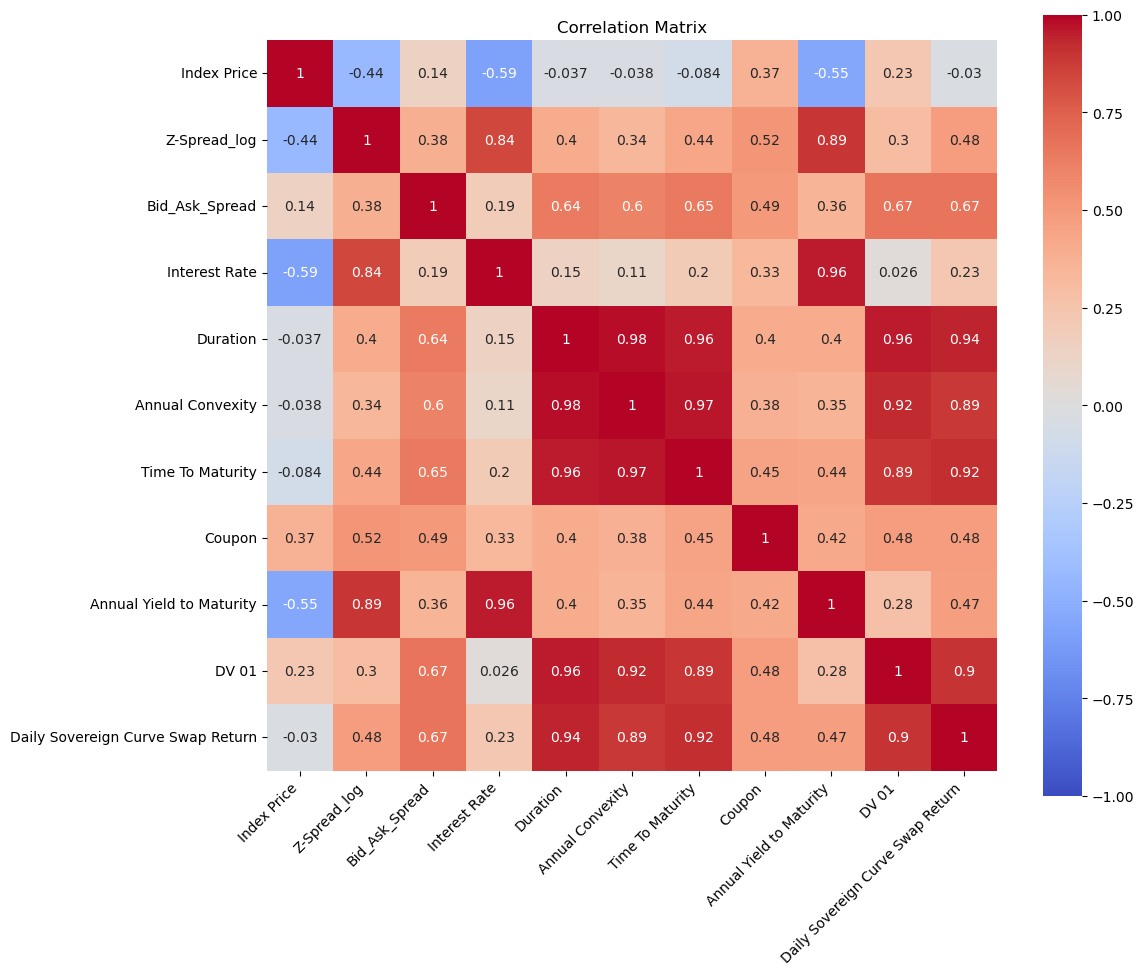

In [18]:
combined_cols = [
    'Index Price', 'Z-Spread_log', 'Bid_Ask_Spread', 'Interest Rate', 'Duration',
    'Annual Convexity', 'Time To Maturity',
    'Coupon', 'Annual Yield to Maturity', 'DV 01', 'Daily Sovereign Curve Swap Return'
]

combined_cols = [col for col in combined_cols if col in df.columns] # Drop duplicates

combined_corr = df[combined_cols].corr()

# Plot a single heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(combined_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### Initial regression

In [20]:
# Index Price Regression
X1 = df[['Interest Rate', 'Annual Convexity', 'Duration','Z-Spread_log', 'Coupon', 'Annual Yield to Maturity', 'Time To Maturity', 'Bid_Ask_Spread']]
y1 = df['Index Price']
X1 = sm.add_constant(X1)
model1 = sm.OLS(y1, X1).fit(cov_type='HC1')

# Z-spread_log Regression
X2 = df[['Interest Rate', 'Time To Maturity', 'Index Price', 'Duration', 'Bid_Ask_Spread', 'Coupon', 'Annual Yield to Maturity']]
y2 = df['Z-Spread_log']
X2 = sm.add_constant(X2)
model2 = sm.OLS(y2, X2).fit(cov_type='HC1')

# Liquidity Regression
X3 = df[['Interest Rate', 'Duration', 'Time To Maturity', 'Annual Convexity', 'Coupon', 'DV 01', 'Index Price', 'Z-Spread_log', 'Daily Sovereign Curve Swap Return']]
y3 = df['Bid_Ask_Spread']
X3 = sm.add_constant(X3)
model3 = sm.OLS(y3, X3).fit(cov_type='HC1')

##### Feature selection

In [24]:
# Function to calculate VIF
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Function to drop variables with high VIF
def drop_high_vif(X, threshold=10.0, const_col='const'):
    while True:
        vif = calculate_vif(X)
        # Exclude constant column from consideration when checking VIF
        vif_non_const = vif[vif["Variable"] != const_col]
        if vif_non_const.empty:
            break
        max_vif = vif_non_const["VIF"].max()
        if max_vif > threshold:
            drop_var = vif_non_const.sort_values("VIF", ascending=False)["Variable"].iloc[0]
            print(f"Dropping '{drop_var}' with VIF: {max_vif}")
            X = X.drop(columns=[drop_var])
        else:
            break
    return X

# Dropped variables with high VIF
print("--- VIF Reduction Process ---")
print("\nModel 1:")
X1_final = drop_high_vif(X1.copy(), const_col='const')
print("\nModel 2:")
X2_final = drop_high_vif(X2.copy(), const_col='const')
print("\nModel 3:")
X3_final = drop_high_vif(X3.copy(), const_col='const')

# Target variables 
y1 = df['Index Price']
y2 = df['Z-Spread_log']
y3 = df['Bid_Ask_Spread']

# Run regressions
model1 = sm.OLS(y1, X1_final).fit(cov_type='HC1')
model2 = sm.OLS(y2, X2_final).fit(cov_type='HC1')
model3 = sm.OLS(y3, X3_final).fit(cov_type='HC1')

--- VIF Reduction Process ---

Model 1:
Dropping 'Annual Yield to Maturity' with VIF: 185.15547160455495
Dropping 'Annual Convexity' with VIF: 39.78211724468638
Dropping 'Time To Maturity' with VIF: 13.21564960376088

Model 2:
Dropping 'Annual Yield to Maturity' with VIF: 137.9647920899394
Dropping 'Time To Maturity' with VIF: 14.879522991590537

Model 3:
Dropping 'Duration' with VIF: 330.37191845111664
Dropping 'Annual Convexity' with VIF: 38.682390708930086
Dropping 'DV 01' with VIF: 18.018200435887188


In [26]:
# Function to drop coefficients with high p-values
def drop_high_pvals(X, y, threshold=0.05):
    X = X.copy()
    while True:
        model = sm.OLS(y, X).fit(cov_type='HC1')
        # Exclude constant and 'Interest Rate' from the p-values used for dropping
        pvals = model.pvalues.drop(labels=['const', 'Interest Rate'], errors='ignore')
        if pvals.empty:
            break
        max_pval = pvals.max()
        if max_pval > threshold:
            drop_var = pvals.idxmax()
            print(f"Dropping '{drop_var}' with p-value: {max_pval:.4f}")
            X = X.drop(columns=[drop_var])
        else:
            break
    final_model = sm.OLS(y, X).fit(cov_type='HC1')
    return final_model

print("--- High p-value Coefficients ---")
print("\nModel 1:")
model1 = drop_high_pvals(X1_final, y1)
print("\nModel 2:")
model2 = drop_high_pvals(X2_final, y2)
print("\nModel 3:")
model3 = drop_high_pvals(X3_final, y3)

--- High p-value Coefficients ---

Model 1:

Model 2:

Model 3:


##### Final regression

In [29]:
print("\nModel 1: Price Regression Summary")
print(model1.summary())

print("\nModel 2: Z-spread Regression Summary")
print(model2.summary())

print("\nModel 3: Liquidity Regression Summary")
print(model3.summary())


Model 1: Price Regression Summary
                            OLS Regression Results                            
Dep. Variable:            Index Price   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     306.0
Date:                Mon, 07 Apr 2025   Prob (F-statistic):          6.00e-225
Time:                        14:28:16   Log-Likelihood:                -4701.4
No. Observations:                1482   AIC:                             9415.
Df Residuals:                    1476   BIC:                             9447.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const    

#### Validation

##### Residual analysis

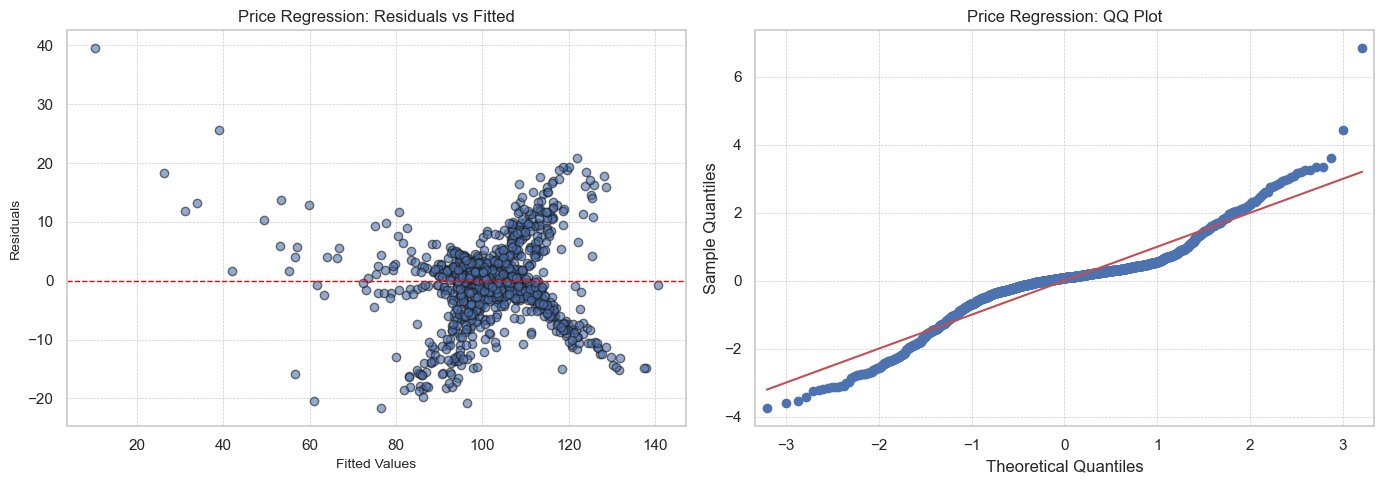

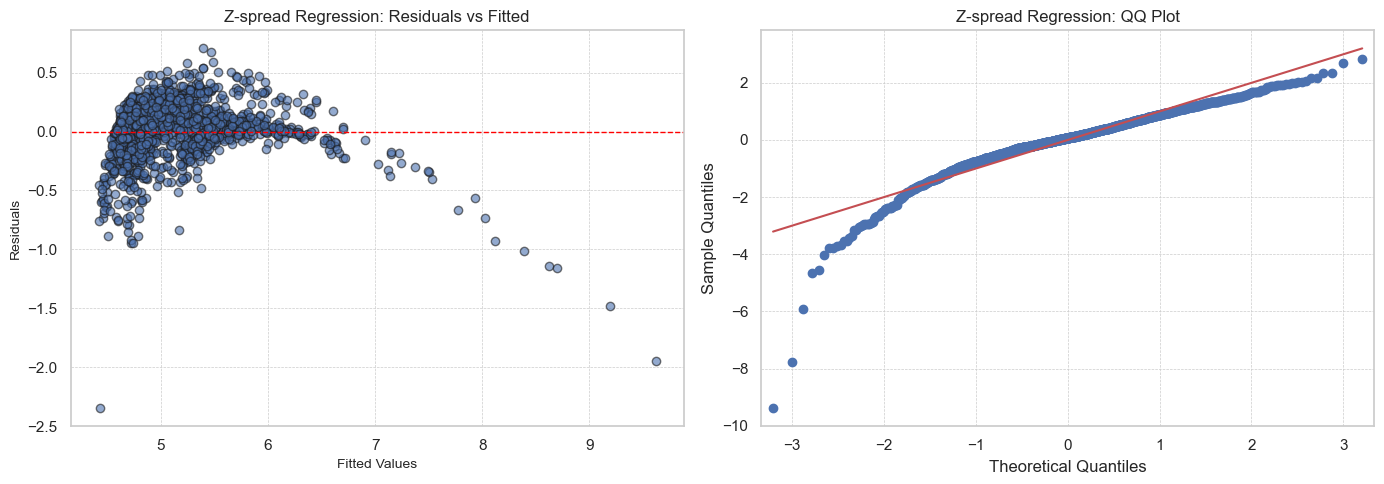

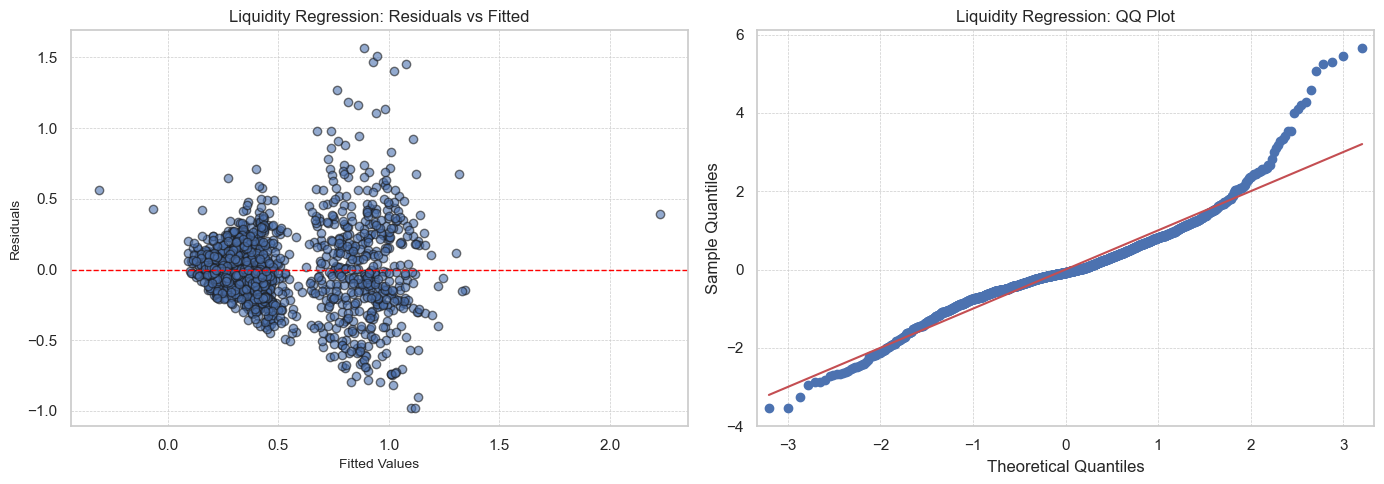

In [33]:
def residual_analysis(model, model_name="Model", save_path=None):
    residuals = model.resid
    fitted = model.fittedvalues

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Residuals vs Fitted Plot
    axes[0].scatter(fitted, residuals, alpha=0.6, edgecolors='k')
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0].set_xlabel("Fitted Values", fontsize=10)
    axes[0].set_ylabel("Residuals", fontsize=10)
    axes[0].set_title(f"{model_name}: Residuals vs Fitted", fontsize=12)
    axes[0].grid(True, linestyle='--', linewidth=0.5)

    # QQ Plot
    sm.qqplot(residuals, line='s', fit=True, ax=axes[1])
    axes[1].set_title(f"{model_name}: QQ Plot", fontsize=12)
    axes[1].grid(True, linestyle='--', linewidth=0.5)

    plt.tight_layout()
    plt.show()

residual_analysis(model1, model_name="Price Regression", save_path="price_residuals.png")
residual_analysis(model2, model_name="Z-spread Regression", save_path="zspread_residuals.png")
residual_analysis(model3, model_name="Liquidity Regression", save_path="liquidity_residuals.png")

##### Error metrics

In [35]:
def error_metrics(model, model_name="Model"):
    
    # Extract actual and predicted values
    actual = model.model.endog      # Actual values from the model
    predicted = model.fittedvalues  # Fitted/predicted values from the model
    residuals = actual - predicted  # Residuals

    # Calculate error metrics
    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    
    print(f"\n{model_name} Error Metrics:")
    print(f"Mean Absolute Error (MAE): {mae:.3f}")
    print(f"Mean Squared Error (MSE): {mse:.3f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

metrics_model1 = error_metrics(model1, model_name="Model 1: Price")
metrics_model2 = error_metrics(model2, model_name="Model 2: Z-spread")
metrics_model3 = error_metrics(model3, model_name="Model 3: Liquidity")


Model 1: Price Error Metrics:
Mean Absolute Error (MAE): 3.754
Mean Squared Error (MSE): 33.341
Root Mean Squared Error (RMSE): 5.774

Model 2: Z-spread Error Metrics:
Mean Absolute Error (MAE): 0.176
Mean Squared Error (MSE): 0.063
Root Mean Squared Error (RMSE): 0.250

Model 3: Liquidity Error Metrics:
Mean Absolute Error (MAE): 0.193
Mean Squared Error (MSE): 0.077
Root Mean Squared Error (RMSE): 0.277


## Agent-Based Model

#### Model

In [40]:
class abm:
    def __init__(self):
        # Sets up the initial structure of the model.
        self.n_agents = 0  # total number of bond agents
        self.agents = []   # list of bond's ISINs
        self.agent_attributes = {}  # dictionary to store bond attributes

    def initialize(self, df):
        # Fills the model with bond agents using the bond dataframe.
        self.n_agents = len(df)
        self.agents = df['ISIN'].tolist()
        self.agent_attributes = {}
        self.agent_history = {}

        for _, row in df.iterrows():
            agent_id = row['ISIN']
            self.agent_attributes[agent_id] = {
                'ISIN': agent_id,
                'Issuer Country': row['Issuer Country'],
                'Level 5': row['Level 5'],
                'Duration': row['Duration'],
                'Annual Convexity': row['Annual Convexity'],
                'Annual Yield to Maturity': row['Annual Yield to Maturity'],
                'Index Price': row['Index Price'],
                'Bid_Ask_Spread': row['Bid_Ask_Spread'],
                'Z-Spread_log': row['Z-Spread_log'],
                'Annual Benchmark Spread': row['Annual Benchmark Spread'],
                'Time To Maturity': row['Time To Maturity'],
                'Markit iBoxx Rating': row['Markit iBoxx Rating'],
                'Coupon': row['Coupon'],
            }
            self.agent_history[agent_id] = {
                'Index Price': [row['Index Price']],
                'Z-Spread_log': [row['Z-Spread_log']],
                'Bid_Ask_Spread': [row['Bid_Ask_Spread']]
            }

    def simulate_interest_rate_shock(self, delta_rate, coefficients_dict, dependent_var_mapping, shock_std=0.01, log_history=True):
        for model_name, coefs in coefficients_dict.items():
            baseline_var = dependent_var_mapping[model_name]
            implied_rate_coef = coefs.get("Interest Rate", 0)
            shock_effect = implied_rate_coef * delta_rate
            for agent_id, attrs in self.agent_attributes.items():
                # Incorporate stochastic noise in the shock effect.
                noise = np.random.normal(0, shock_std)
                attrs[baseline_var] += shock_effect + noise
                if log_history:
                    self.agent_history[agent_id][baseline_var].append(attrs[baseline_var])

    def simulate_propagation(self, price_coef, spread_coef, liquidity_coef, propagation_std=0.01, log_history=True):
        # Define peers based on Markit iBoxx Rating.
        peers = {}
        for agent_id, attrs in self.agent_attributes.items():
            rating = attrs['Markit iBoxx Rating']
            peers.setdefault(rating, []).append(agent_id)
        
        # Iterate over each peer group.
        for rating, agent_ids in peers.items():
            price_changes = []
            spread_changes = []
            liquidity_changes = []
            
            # Compute changes within this peer group.
            for agent_id in agent_ids:
                # Price change.
                price_history = self.agent_history[agent_id]['Index Price']
                price_change = price_history[-1] - price_history[-2] if len(price_history) >= 2 else 0
                price_changes.append(price_change)
                # Z-Spread change.
                spread_history = self.agent_history[agent_id]['Z-Spread_log']
                spread_change = spread_history[-1] - spread_history[-2] if len(spread_history) >= 2 else 0
                spread_changes.append(spread_change)
                # Liquidity change.
                liquidity_history = self.agent_history[agent_id]['Bid_Ask_Spread']
                liquidity_change = liquidity_history[-1] - liquidity_history[-2] if len(liquidity_history) >= 2 else 0
                liquidity_changes.append(liquidity_change)
            
            avg_price_change = sum(price_changes) / len(price_changes) if price_changes else 0
            avg_spread_change = sum(spread_changes) / len(spread_changes) if spread_changes else 0
            avg_liquidity_change = sum(liquidity_changes) / len(liquidity_changes) if liquidity_changes else 0
                
            # Propagate the average changes to each bond in the group with noise.
            for agent_id in agent_ids:
                noise_price = np.random.normal(0, propagation_std)
                noise_spread = np.random.normal(0, propagation_std)
                noise_liquidity = np.random.normal(0, propagation_std)
                
                adjustment_price = price_coef * avg_price_change + noise_price
                self.agent_attributes[agent_id]['Index Price'] += adjustment_price
    
                adjustment_spread = spread_coef * avg_spread_change + noise_spread
                self.agent_attributes[agent_id]['Z-Spread_log'] += adjustment_spread
    
                adjustment_liquidity = liquidity_coef * avg_liquidity_change + noise_liquidity
                self.agent_attributes[agent_id]['Bid_Ask_Spread'] += adjustment_liquidity
    
                if log_history:
                    self.agent_history[agent_id]['Index Price'].append(self.agent_attributes[agent_id]['Index Price'])
                    self.agent_history[agent_id]['Z-Spread_log'].append(self.agent_attributes[agent_id]['Z-Spread_log'])
                    self.agent_history[agent_id]['Bid_Ask_Spread'].append(self.agent_attributes[agent_id]['Bid_Ask_Spread'])

## Simulation

In [45]:
def run_simulation(df, delta_rate, time_steps=3600,
                   price_coef=0.5, spread_coef=0.5, liquidity_coef=0.5,
                   model1=None, model2=None, model3=None):
    
    # Initialize the agent-based model
    market_abm = abm()
    market_abm.initialize(df)

    # Define coefficient mappings for the models
    coefficients_dict = {
        "Model 1 (Price)": model1.params,
        "Model 2 (Z-spread)": model2.params,
        "Model 3 (Liquidity)": model3.params
    }
    dependent_var_mapping = {
        "Model 1 (Price)": "Index Price",
        "Model 2 (Z-spread)": "Z-Spread_log",
        "Model 3 (Liquidity)": "Bid_Ask_Spread"
    }

    # Run the simulation over time
    for t in range(time_steps):
        # Apply interest rate shock and propagation
        market_abm.simulate_interest_rate_shock(delta_rate, coefficients_dict, dependent_var_mapping, log_history=False)
        market_abm.simulate_propagation(price_coef, spread_coef, liquidity_coef, log_history=False)

        # Log agent states
        for agent_id in market_abm.agents:
            market_abm.agent_history[agent_id]['Index Price'].append(
                market_abm.agent_attributes[agent_id]['Index Price'])
            market_abm.agent_history[agent_id]['Z-Spread_log'].append(
                market_abm.agent_attributes[agent_id]['Z-Spread_log'])
            market_abm.agent_history[agent_id]['Bid_Ask_Spread'].append(
                market_abm.agent_attributes[agent_id]['Bid_Ask_Spread'])

    return market_abm 

## Results

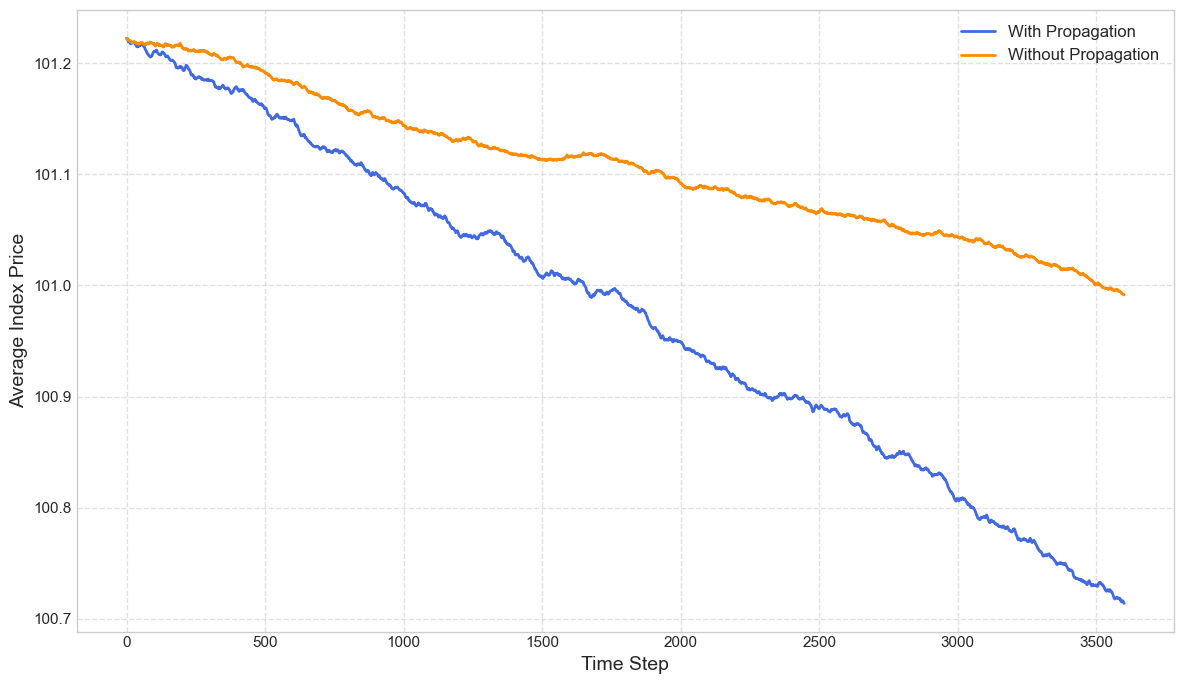

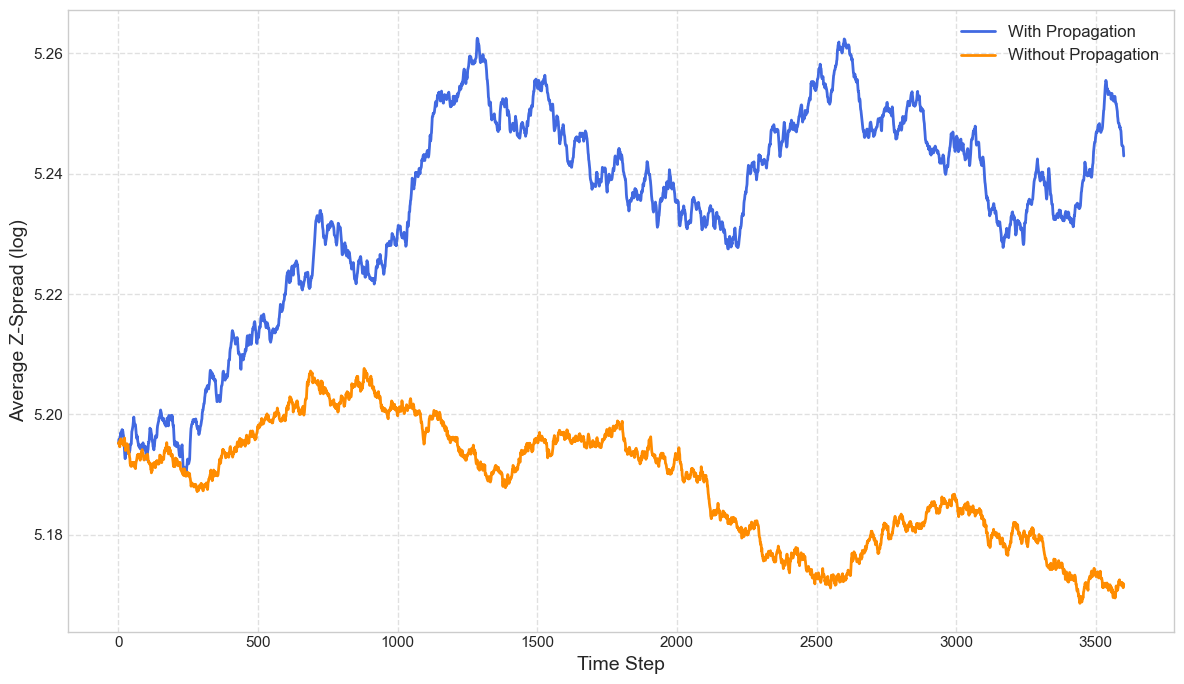

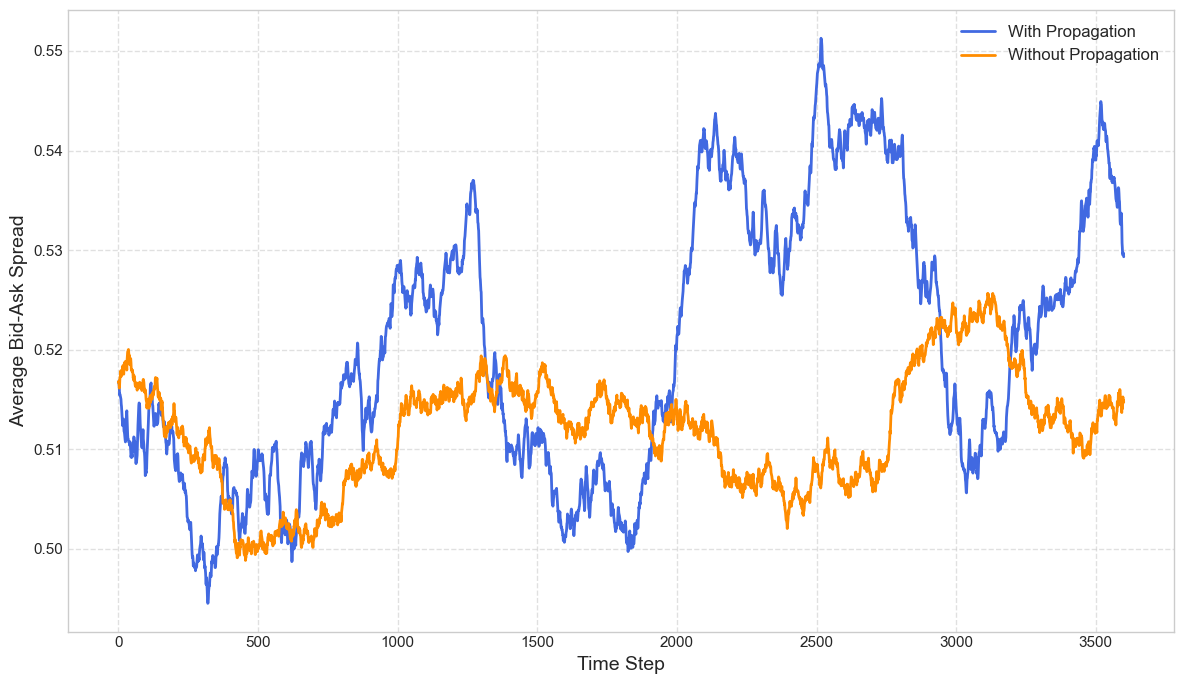

In [49]:
def plot_simulation_results(sim_with, sim_without):
    def compute_average_time_series(sim, key):
        # Calculate the average value across all agents for each time step.
        n_agents = len(sim.agents)
        history_length = len(next(iter(sim.agent_history.values()))[key])
        avg_series = []
        for t in range(history_length):
            avg_value = sum(sim.agent_history[agent][key][t] for agent in sim.agents) / n_agents
            avg_series.append(avg_value)
        return avg_series

    # Compute average time series for each metric from both simulations.
    price_with     = compute_average_time_series(sim_with, 'Index Price')
    price_without  = compute_average_time_series(sim_without, 'Index Price')
    
    spread_with    = compute_average_time_series(sim_with, 'Z-Spread_log')
    spread_without = compute_average_time_series(sim_without, 'Z-Spread_log')
    
    liquidity_with    = compute_average_time_series(sim_with, 'Bid_Ask_Spread')
    liquidity_without = compute_average_time_series(sim_without, 'Bid_Ask_Spread')

    time_steps = range(len(price_with))

    # --- Index Price ---
    plt.figure(figsize=(12, 7))
    plt.plot(time_steps, price_with, label='With Propagation', linewidth=2, color='royalblue')
    plt.plot(time_steps, price_without, label='Without Propagation', linewidth=2, color='darkorange')
    plt.xlabel("Time Step", fontsize=14)
    plt.ylabel("Average Index Price", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # --- Z-Spread (log) ---
    plt.figure(figsize=(12, 7))
    plt.plot(time_steps, spread_with, label='With Propagation', linewidth=2, color='royalblue')
    plt.plot(time_steps, spread_without, label='Without Propagation', linewidth=2, color='darkorange')
    plt.xlabel("Time Step", fontsize=14)
    plt.ylabel("Average Z-Spread (log)", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # --- Bid-Ask Spread (Liquidity) ---
    plt.figure(figsize=(12, 7))
    plt.plot(time_steps, liquidity_with, label='With Propagation', linewidth=2, color='royalblue')
    plt.plot(time_steps, liquidity_without, label='Without Propagation', linewidth=2, color='darkorange')
    plt.xlabel("Time Step", fontsize=14)
    plt.ylabel("Average Bid-Ask Spread", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()    
    
# Simulation with propagation:
abm_with = run_simulation(df, delta_rate=0.002, time_steps=3600,
                          price_coef=0.5, spread_coef=0.5, liquidity_coef=0.5,
                          model1=model1, model2=model2, model3=model3)

# Simulation without propagation (set coefficients to zero):
abm_without = run_simulation(df, delta_rate=0.002, time_steps=3600,
                             price_coef=0.0, spread_coef=0.0, liquidity_coef=0.0,
                             model1=model1, model2=model2, model3=model3)

plot_simulation_results(abm_with, abm_without)